# Annotation Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# read annotation file
df_annotation = pd.read_csv('../data/annotations_combined.csv')
df_annotation.head()

,img_id,group_id,hair_1,pen_1,hair_2,pen_2,hair_3,pen_3,hair_4,pen_4,hair_5,pen_5
0,PAT_1431_1495_511.png,a,2.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,NaN,NaN
1,PAT_2051_4356_460.png,a,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN
2,PAT_1255_876_939.png,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN
3,PAT_963_1820_823.png,a,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,NaN
4,PAT_419_832_706.png,a,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,NaN,NaN


In [2]:
# preprocessing annotations

# keep only relevant cols
df_annotation.drop(columns = 'group_id', inplace = True) 
df_annotation.drop_duplicates(inplace = True)

print('Before')
print(f'cols: {df_annotation.shape[1]}, rows: {df_annotation.shape[0]}')

# drop rows with all NA values
df_annotation.dropna(how='all', inplace = True)

print(df_annotation.head())

print()

# change all NA values to 0
df_annotation.fillna(value = 0, inplace = True)

print('After')
print(f'cols: {df_annotation.shape[1]}, rows: {df_annotation.shape[0]}')
print(df_annotation.head())

Before
cols: 11, rows: 1637
                  img_id  hair_1  pen_1  hair_2  pen_2  hair_3  pen_3  hair_4  \
0  PAT_1431_1495_511.png     2.0    0.0     1.0    0.0     2.0    0.0     1.0   
1  PAT_2051_4356_460.png     2.0    1.0     1.0    1.0     1.0    1.0     1.0   
2   PAT_1255_876_939.png     0.0    0.0     0.0    0.0     0.0    0.0     0.0   
3   PAT_963_1820_823.png     1.0    0.0     1.0    0.0     1.0    0.0     0.0   
4    PAT_419_832_706.png     0.0    1.0     0.0    1.0     0.0    1.0     0.0   

   pen_4  hair_5  pen_5  
0    0.0     NaN    NaN  
1    0.0     NaN    NaN  
2    1.0     NaN    NaN  
3    1.0     NaN    NaN  
4    1.0     NaN    NaN  

After
cols: 11, rows: 1636
                  img_id  hair_1  pen_1  hair_2  pen_2  hair_3  pen_3  hair_4  \
0  PAT_1431_1495_511.png     2.0    0.0     1.0    0.0     2.0    0.0     1.0   
1  PAT_2051_4356_460.png     2.0    1.0     1.0    1.0     1.0    1.0     1.0   
2   PAT_1255_876_939.png     0.0    0.0     0.0    0.0    

In [3]:
# Separate columns for hair and pen marks
hair_cols = [col for col in df_annotation.columns if "hair" in col]
pen_cols = [col for col in df_annotation.columns if "pen" in col]


# modify annotations (voting)
df_annotation['hair_rating'] =df_annotation[hair_cols].apply(
    lambda row: row.mode().max(), axis=1
)
df_annotation['pen_rating'] =df_annotation[pen_cols].apply(
    lambda row: row.mode().max(), axis=1
)

In [4]:
# Agreement Score

def agreement_score(row):
    return row.value_counts(normalize=True).max()

df_annotation["hair_agreement"] = df_annotation[hair_cols].apply(agreement_score, axis=1)
df_annotation["pen_agreement"] = df_annotation[pen_cols].apply(agreement_score, axis=1)

Interpretation:

- 1.0 → full agreement
- 0.6 → moderate agreement
- 0.2–0.4 → low agreement

In [5]:
# Cases when annotators disagree (threshold = 0.6)

low_agreement = df_annotation[
    (df_annotation["hair_agreement"] < 0.6) |
    (df_annotation["pen_agreement"] < 0.6)
]

low_agreement 

,img_id,hair_1,pen_1,hair_2,pen_2,hair_3,pen_3,hair_4,pen_4,hair_5,pen_5,hair_rating,pen_rating,hair_agreement,pen_agreement
0,PAT_1431_1495_511.png,2.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.4,1.0
6,PAT_1701_3135_5.png,3.0,0.0,2.0,0.0,3.0,0.0,2.0,1.0,0.0,0.0,3.0,0.0,0.4,0.8
7,PAT_216_331_678.png,3.0,0.0,1.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0,3.0,0.0,0.4,0.6
12,PAT_372_760_267.png,2.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.4,0.8
16,PAT_1947_3926_165.png,2.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.4,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,PAT_961_1818_992,3.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,0.4,1.0
1249,PAT_966_1825_584,3.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,0.4,1.0
1282,PAT_2016_4160_868,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.4,1.0
1554,PAT_330_1440_532.png,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1.0,0.0,1.0,0.0,0.4,0.8


In [6]:
from statsmodels.stats.inter_rater import fleiss_kappa
import numpy as np

def compute_fleiss_kappa(df_subset):
    categories = sorted(pd.unique(df_subset.values.ravel()))
    
    matrix = []
    for _, row in df_subset.iterrows():
        counts = row.value_counts()
        row_counts = [counts.get(cat, 0) for cat in categories]
        matrix.append(row_counts)
    
    return fleiss_kappa(np.array(matrix))

hair_kappa = compute_fleiss_kappa(df_annotation[hair_cols])
pen_kappa = compute_fleiss_kappa(df_annotation[pen_cols])

print("Hair Fleiss' Kappa:", hair_kappa)
print("Pen Fleiss' Kappa:", pen_kappa)

Hair Fleiss' Kappa: 0.6271427161893804
Pen Fleiss' Kappa: 0.8161175030892192


In [7]:
print("Hair agreement mean:", df_annotation["hair_agreement"].mean())
print("Pen agreement mean:", df_annotation["pen_agreement"].mean())

Hair agreement mean: 0.8553789731051346
Pen agreement mean: 0.962591687041565


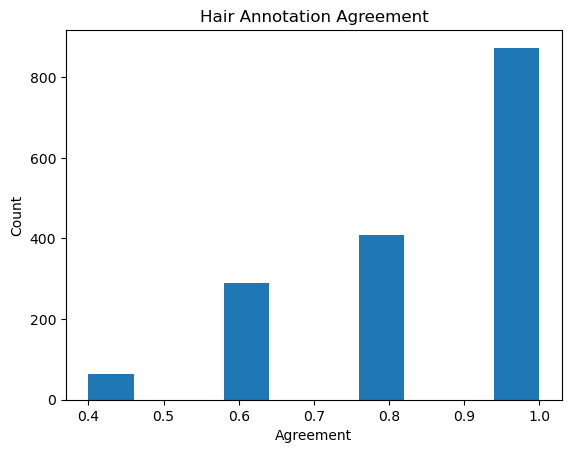

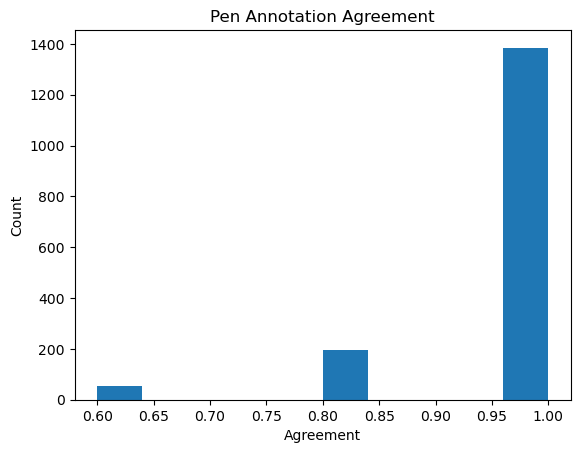

In [8]:
import matplotlib.pyplot as plt

plt.hist(df_annotation["hair_agreement"], bins=10)
plt.title("Hair Annotation Agreement")
plt.xlabel("Agreement")
plt.ylabel("Count")
plt.show()

plt.hist(df_annotation["pen_agreement"], bins=10)
plt.title("Pen Annotation Agreement")
plt.xlabel("Agreement")
plt.ylabel("Count")
plt.show()

In [9]:
for col in hair_cols:
    agreement = (df_annotation[col] == df_annotation["hair_rating"]).mean()
    print(f"{col} vs majority:", agreement)

hair_1 vs majority: 0.8661369193154034
hair_2 vs majority: 0.8429095354523227
hair_3 vs majority: 0.878361858190709
hair_4 vs majority: 0.8636919315403423
hair_5 vs majority: 0.8257946210268948


#### Agreement Heatmaps matrix

In [38]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd

def agreement_matrix(df_subset):
    cols = df_subset.columns
    matrix = pd.DataFrame(index=cols, columns=cols)

    for col1 in cols:
        for col2 in cols:
            agreement = (df_subset[col1] == df_subset[col2]).mean()
            matrix.loc[col1, col2] = agreement

    return matrix.astype(float)


def kappa_matrix(df_subset):
    cols = df_subset.columns
    matrix = pd.DataFrame(index=cols, columns=cols)

    for col1 in cols:
        for col2 in cols:
            score = cohen_kappa_score(df_subset[col1], df_subset[col2])
            matrix.loc[col1, col2] = score

    return matrix.astype(float)



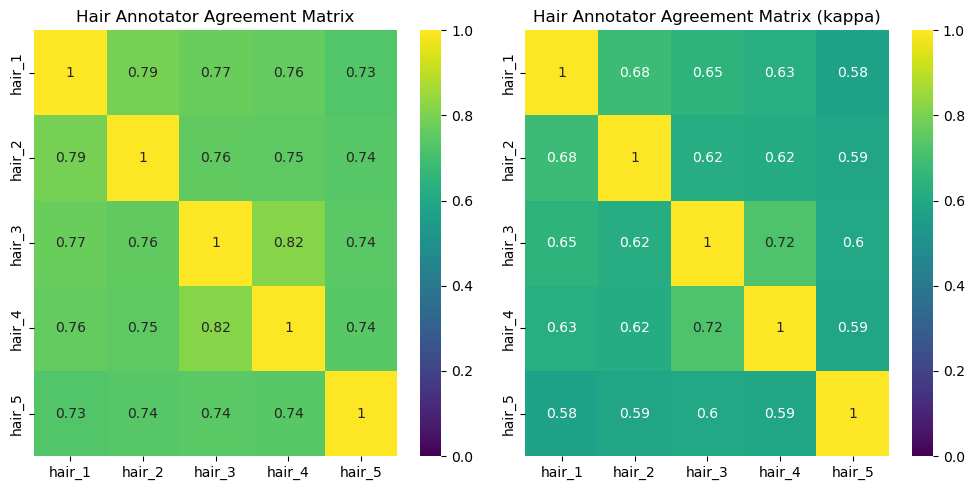

In [39]:
import matplotlib.pyplot as  plt
import seaborn as sns

hair_cols = ['hair_1', 'hair_2', 'hair_3', 'hair_4', 'hair_5']
hair_df = df_annotation[hair_cols]

hair_agreement_matrix = agreement_matrix(hair_df)
hair_kappa_matrix = kappa_matrix(hair_df)

fig, ax = plt.subplots(1,2, figsize = (10,5)) # hair annotation
sns.heatmap(hair_agreement_matrix, annot= True, cmap = 'viridis', vmin=0, vmax=1, ax = ax[0])
sns.heatmap(hair_kappa_matrix, annot= True, cmap = 'viridis', vmin=0, vmax=1, ax = ax[1])
ax[0].set_title("Hair Annotator Agreement Matrix")
ax[1].set_title("Hair Annotator Agreement Matrix (kappa)")
plt.tight_layout()
plt.show()

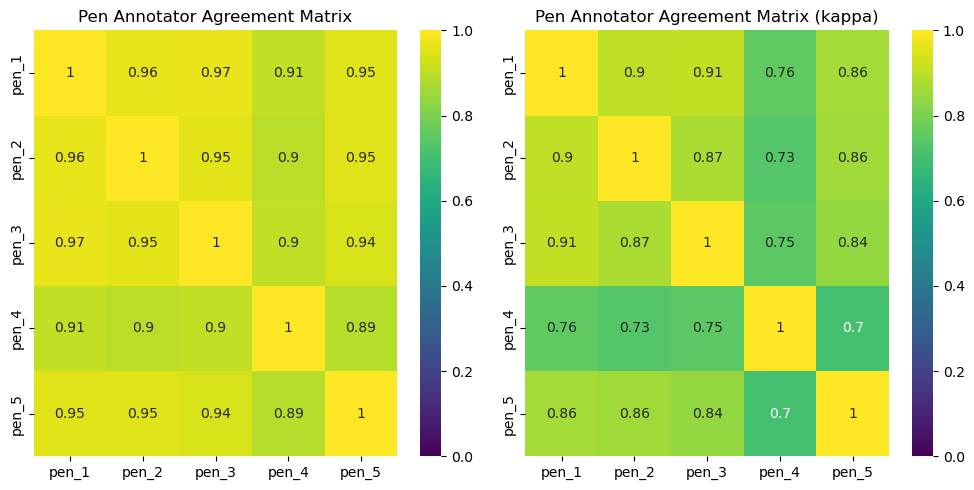

In [40]:
pen_cols = ['pen_1', 'pen_2', 'pen_3', 'pen_4', 'pen_5']
pen_df = df_annotation[pen_cols]

pen_kappa_matrix = kappa_matrix(pen_df)
pen_agreement_matrix = agreement_matrix(pen_df)

fig, ax = plt.subplots(1,2, figsize = (10,5)) # pen annotation
sns.heatmap(pen_agreement_matrix, annot= True, cmap = 'viridis', vmin=0, vmax=1, ax = ax[0])
sns.heatmap(pen_kappa_matrix, annot= True, cmap = 'viridis', vmin=0, vmax=1, ax = ax[1])
ax[0].set_title("Pen Annotator Agreement Matrix")
ax[1].set_title("Pen Annotator Agreement Matrix (kappa)")
plt.tight_layout()
plt.show()

In [43]:
# Saved clean annotation file
df_annotation.to_csv('../data/annotations.csv')

# Hair Analysis

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import skimage.measure
import skimage.morphology as morph
from joblib import Parallel, delayed

# =========================
# 1. PATHS 
# =========================
IMAGE_DIR = "../data/imgs/"
MASK_DIR = "../data/masks/"

# =========================
# 2. LOAD FUNCTIONS
# =========================
def load_image(img_id):
    path = os.path.join(IMAGE_DIR, img_id)
    if not os.path.exists(path):
        print(f"Image not found: {img_id}")
        return None
    image = cv2.imread(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def load_mask(img_id):
    path = os.path.join(MASK_DIR, img_id.replace('.png', '_mask.png'))
    if not os.path.exists(path):
        print(f"Mask not found: {img_id}")
        return None
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return mask


# =========================
# 3. LARGEST LESION MASK
# =========================
def modified_mask(mask):
    binary_mask = (mask > 0.5)
    
    if np.sum(binary_mask) == 0:
        return binary_mask
    
    labeled = skimage.measure.label(binary_mask)
    props = skimage.measure.regionprops(labeled)
    
    if len(props) == 1:
        return binary_mask
    
    largest_region = max(props, key=lambda r: r.area)
    
    return (labeled == largest_region.label)


# =========================
# 4. HAIR DETECTION
# =========================
def detect_hair_mask(image, ksize=3):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (ksize, ksize))

    # Dark hair
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, black_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Light hair
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    _, white_mask = cv2.threshold(tophat, 10, 255, cv2.THRESH_BINARY)

    # Combine
    hair_mask = cv2.bitwise_or(black_mask, white_mask)

    # Convert to binary
    hair_mask = (hair_mask > 0)

    # Slight dilation
    hair_mask = cv2.dilate(hair_mask.astype(np.uint8), np.ones((2,2), np.uint8), iterations=1)

    return hair_mask.astype(np.uint8)


# =========================
# 5. COVERAGE COMPUTATION
# =========================
def compute_hair_coverage(img_id):
    try:
        image = load_image(img_id)
        mask = load_mask(img_id)

        if image is None or mask is None:
            return None

        lesion_mask = modified_mask(mask)
        hair_mask = detect_hair_mask(image)

        # Resize if needed
        if lesion_mask.shape != hair_mask.shape:
            hair_mask = cv2.resize(
                hair_mask,
                (lesion_mask.shape[1], lesion_mask.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        lesion_mask = (lesion_mask > 0)
        hair_mask = (hair_mask > 0)

        lesion_pixels = np.sum(lesion_mask)

        # Edge case
        if lesion_pixels == 0:
            print(f"{img_id}: Empty lesion")
            return None

        hair_pixels = np.sum(np.logical_and(hair_mask, lesion_mask))

        coverage = hair_pixels / lesion_pixels

        # Sanity check
        if not (0 <= coverage <= 1):
            print(f"{img_id}: Invalid coverage {coverage}")
            return None

        return coverage

    except Exception as e:
        print(f"{img_id} failed: {e}")
        return None


# =========================
# 6. APPLY TO DATAFRAME
# =========================
def compute_all(df, parallel=True):
    if parallel:
        results = Parallel(n_jobs=-1)(
            delayed(compute_hair_coverage)(img_id)
            for img_id in df["img_id"]
        )
    else:
        results = []
        for i, img_id in enumerate(df["img_id"]):
            results.append(compute_hair_coverage(img_id))
            if i % 50 == 0:
                print(f"Processed {i}")

    df["hair_coverage"] = results
    return df


# =========================
# 7. DEBUG FUNCTION
# =========================
import matplotlib.pyplot as plt

def debug_image(img_id):
    image = load_image(img_id)
    mask = load_mask(img_id)

    lesion = modified_mask(mask)
    hair = detect_hair_mask(image)

    overlap = hair * lesion

    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.title("Image")
    plt.imshow(image)

    plt.subplot(1,4,2)
    plt.title("Lesion")
    plt.imshow(lesion, cmap='gray')

    plt.subplot(1,4,3)
    plt.title("Hair")
    plt.imshow(hair, cmap='gray')

    plt.subplot(1,4,4)
    plt.title("Hair ∩ Lesion")
    plt.imshow(overlap, cmap='gray')

    plt.show()

In [307]:
df_hair = df_annotation[['img_id', *hair_cols, 'hair_rating', 'hair_agreement', 'pen_agreement']]
df_hair['hair_coverage'] = 0
df_hair.head()

,img_id,hair_1,hair_2,hair_3,hair_4,hair_5,hair_rating,hair_agreement,pen_agreement,hair_coverage
0,PAT_1431_1495_511.png,2.0,1.0,2.0,1.0,0.0,2.0,0.4,1.0,0
1,PAT_2051_4356_460.png,2.0,1.0,1.0,1.0,0.0,1.0,0.6,0.6,0
2,PAT_1255_876_939.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.8,0
3,PAT_963_1820_823.png,1.0,1.0,1.0,0.0,0.0,1.0,0.6,0.8,0
4,PAT_419_832_706.png,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.8,0


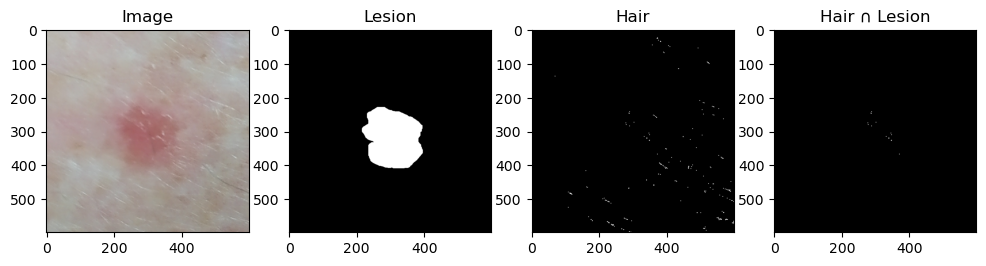

In [327]:
debug_image('PAT_963_1820_823.png')

In [308]:
df_hair  = compute_all(df_hair)

Image not found: PAT_32_44_211
Mask not found: PAT_32_44_211
Image not found: PAT_35_48_43
Mask not found: PAT_35_48_43
Image not found: PAT_50_76_728
Mask not found: PAT_50_76_728
Image not found: PAT_74_112_729
Mask not found: PAT_74_112_729
Image not found: PAT_90_139_57
Mask not found: PAT_90_139_57
Image not found: PAT_141_209_438
Mask not found: PAT_141_209_438
Image not found: PAT_151_227_63
Mask not found: PAT_151_227_63
Image not found: PAT_153_1200_541
Mask not found: PAT_153_1200_541
Image not found: PAT_155_240_211
Mask not found: PAT_155_240_211
Image not found: PAT_167_258_711
Mask not found: PAT_167_258_711
Image not found: PAT_190_291_366
Mask not found: PAT_190_291_366
Image not found: PAT_198_853_778
Mask not found: PAT_198_853_778
Image not found: PAT_207_1280_15
Mask not found: PAT_207_1280_15
Image not found: PAT_211_318_942
Mask not found: PAT_211_318_942
Image not found: PAT_237_362_909
Mask not found: PAT_237_362_909
Image not found: PAT_242_368_261
Mask not fou

In [309]:
df_hair.value_counts('hair_coverage', dropna = False)

hair_coverage
0.000000    1073
NaN          234
0.006288       1
0.033015       1
0.024407       1
            ... 
0.000702       1
0.124306       1
0.004131       1
0.074676       1
0.256105       1
Name: count, Length: 331, dtype: int64

In [310]:
# save the dataframe in the data directory
df_hair.to_csv('../data/hair_cvg.csv')

In [311]:
# Read data for hair analysis.
df = pd.read_csv('../data/hair_cvg.csv', index_col = 0)
r,c = df.shape
print(60*'=')
print(f'The dataframe has {r} rows and {c} columns.')

# remove all null values 
df.dropna(inplace = True)
print(f'Number of Null values: {r - df.shape[0]}')
print(60*'=')

The dataframe has 1636 rows and 10 columns.
Number of Null values: 234


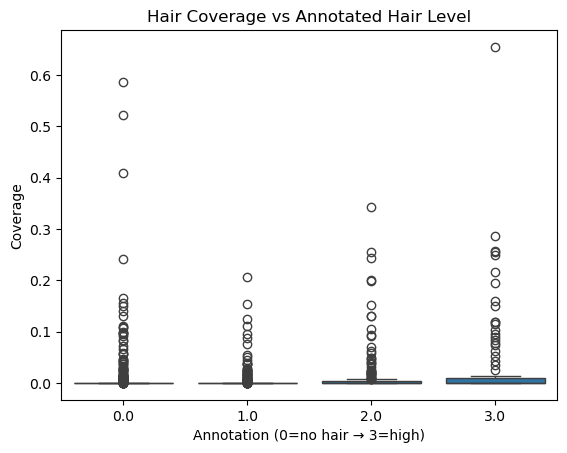

In [312]:
import seaborn as sns
import matplotlib.pyplot as plt

# Relationship: Coverage vs Annotations 

sns.boxplot(x=df["hair_rating"], y=df["hair_coverage"])
plt.title("Hair Coverage vs Annotated Hair Level")
plt.xlabel("Annotation (0=no hair → 3=high)")
plt.ylabel("Coverage")
plt.show()

'''
Interpretation: For all categories, there is a cluster at hair coverage = 0. 
The data is heavily skewed by zeros, and for each category we can also spot outliers. 
There is a clear mismatch between the annotation and hair coverage. For example, for 
hair annotation value 3 we expect relatively higher hair coverage values, we expect 
a cluster to be higher than other categorical values. 

What could be the possible reason for this plot?
The annotations were made by humans, manually, and its annotated value is based on the
entire image, but when we calculate the hair coverage, we are only considering hair 
inside the lesion area. In most of the cases of skin lesion images, the hair is mostly scattered 
outside of the lesion area. 
''';

In [313]:
# Mean coverage per class
mean_cov = df.groupby("hair_rating")["hair_coverage"].mean()
print(mean_cov)

hair_rating
0.0    0.006961
1.0    0.004211
2.0    0.014759
3.0    0.032315
Name: hair_coverage, dtype: float64


In [314]:
corr = df["hair_rating"].corr(df["hair_coverage"], method="spearman")
print("Spearman correlation:", corr)

'''
This Spearman correlation between human annotation and hair coverage
gives a lower value (approx 0.20), which means there is a very weak 
positive relationship. 
''';

Spearman correlation: 0.20437183950367366


In [315]:
# Remove invalid coverage first
df = df[df["hair_coverage"].notna()]

bins = [0.0, 0.05, 0.2, 0.5, 1.0]
labels = [0, 1, 2, 3]

df["coverage_class"] = pd.cut(
    df["hair_coverage"],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)


accuracy = (df["coverage_class"].astype(int) == df["hair_rating"]).mean()
print("Coverage → annotation accuracy:", accuracy)

''' 
Here we are creating our own labels based on the hair_coverage, and 
we are comparing with the human annotations to verify its accuracy.
''';

Coverage → annotation accuracy: 0.48002853067047074


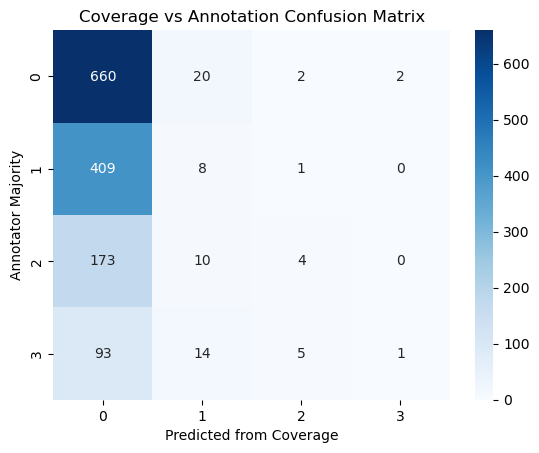

In [316]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(df["hair_rating"], df["coverage_class"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted from Coverage")
plt.ylabel("Annotator Majority")
plt.title("Coverage vs Annotation Confusion Matrix")
plt.show()

In [317]:
print("NaNs in coverage:", df["hair_coverage"].isna().sum())
print("Min:", df["hair_coverage"].min())
print("Max:", df["hair_coverage"].max())

NaNs in coverage: 0
Min: 0.0
Max: 0.6547347634862221


In [318]:
# Normalised hair rating
print(df["hair_rating"].value_counts(normalize = True)) 

print()

# Normalised coverage class
print(df["coverage_class"].value_counts(normalize = True)) 

hair_rating
0.0    0.487874
1.0    0.298146
2.0    0.133381
3.0    0.080599
Name: proportion, dtype: float64

coverage_class
0    0.952211
1    0.037090
2    0.008559
3    0.002140
Name: proportion, dtype: float64


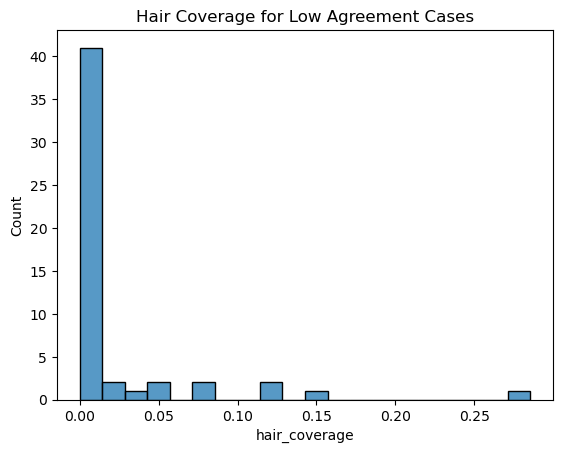

In [319]:
# Hair coverage distribution for low agreement cases
ambiguous = df[df["hair_agreement"] < 0.5]

sns.histplot(ambiguous["hair_coverage"], bins=20)
plt.title("Hair Coverage for Low Agreement Cases")
plt.show()

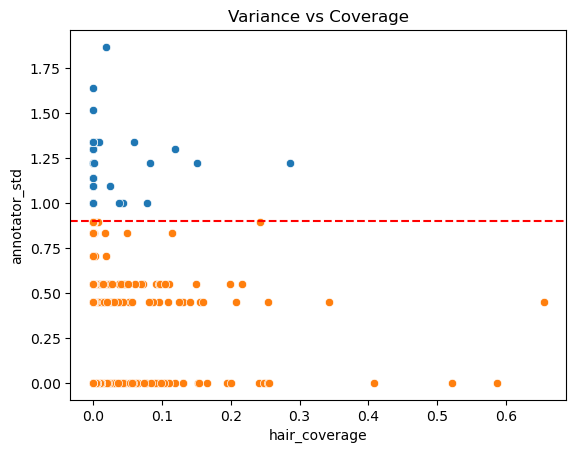

In [320]:
df["annotator_std"] = df[hair_cols].std(axis=1)

# data points with high variance
thresh_std = 0.9
high_var_points = df[df['annotator_std'] >= thresh_std]
low_var_points = df[df['annotator_std'] < thresh_std]

sns.scatterplot(data = high_var_points, x = 'hair_coverage', y = 'annotator_std')
sns.scatterplot(data = low_var_points, x = 'hair_coverage', y = 'annotator_std')

plt.axhline(thresh_std, linestyle = '--', color = 'red')
plt.title("Variance vs Coverage")
plt.show()

''' 
Interpretation: For each image we have its hair coverage and the std deviation
of hair annotators. Data points with higher std deviation have higher disagreement.
For instance, for hair coverage less than 0.3, a lot of images has relatively higher variance 
meaning for low values of hair coverage raters disagree more often then the high values of hair 
coverage.  
''';